# Trees

## 1. Tree Fundamentals

A tree is a hierarchical data structure composed of nodes connected by edges. A tree with n nodes has n-1 edges.

### Terminology

| Term | Definition |
|------|-----------|
| Root | The topmost node with no parent |
| Leaf | A node with no children (degree 0) |
| Degree | Number of children a node has |
| Depth (height) | Maximum number of levels in the tree |
| Parent | Direct predecessor of a node |
| Child | Direct successor of a node |
| Sibling | Nodes sharing the same parent |
| Ancestor | All nodes on the path from a node to the root |
| Descendant | All nodes in the subtree rooted at a node |
| Subtree | A tree formed by a node and all its descendants |

### Classification

- **Ordered tree:** subtrees have a fixed left-right order (e.g. binary tree)
- **Unordered tree:** subtrees can be rearranged freely

## 2. Binary Trees

A binary tree is an ordered tree where each node has at most two children: a left child and a right child.

### Properties

- Level i has at most $2^{i-1}$ nodes
- A tree of depth k has at most $2^k - 1$ nodes
- Number of leaf nodes = number of degree-2 nodes + 1
- A tree with n nodes has n - 1 edges
- Minimum depth for n nodes: $\lceil \log_2(n+1) \rceil$

### Special Binary Trees

| Type | Definition |
|------|-----------|
| **Full** | Every non-leaf node has exactly 2 children; all leaves at same level |
| **Complete** | All levels full except possibly the last, which is filled left to right |
| **BST** | Left subtree values < root < right subtree values |
| **Balanced BST** | Height difference between left and right subtrees <= 1 for every node |

### Storage

**Sequential (array):** store nodes by level order. For node at index `i`:
- Left child: `2i + 1`
- Right child: `2i + 2`
- Parent: `(i - 1) // 2`

**Linked (node class):** each node stores value, left pointer, right pointer.

In [ ]:
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

## 3. Binary Tree Traversals

| Method | Order | Implementation |
|--------|-------|---------------|
| Preorder | root -> left -> right | Recursive or stack |
| Inorder | left -> root -> right | Recursive or stack |
| Postorder | left -> right -> root | Recursive or stack |
| Level-order | Level by level, left to right | Queue (BFS) |

### Preorder (root -> left -> right)

In [ ]:
def preorderRecursive(root):
    res = []

    def dfs(node):
        if not node:
            return
        res.append(node.val)
        dfs(node.left)
        dfs(node.right)

    dfs(root)
    return res


def preorderIterative(root):
    if not root:
        return []
    res = []
    stack = [root]
    while stack:
        node = stack.pop()
        res.append(node.val)
        # right first so left is processed first
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return res

#### Steps

```text
        A
       / \
      B    C
     / \    \
    D   E    F

preorder: A -> B -> D -> E -> C -> F
```

| Step | Visit | Stack (after) |
|------|-------|--------------|
| 1 | A | [C, B] |
| 2 | B | [C, E, D] |
| 3 | D | [C, E] |
| 4 | E | [C] |
| 5 | C | [F] |
| 6 | F | [] |

### Inorder (left -> root -> right)

In [ ]:
def inorderRecursive(root):
    res = []

    def dfs(node):
        if not node:
            return
        dfs(node.left)
        res.append(node.val)
        dfs(node.right)

    dfs(root)
    return res


def inorderIterative(root):
    res = []
    stack = []
    cur = root
    while cur or stack:
        while cur:
            stack.append(cur)
            cur = cur.left
        node = stack.pop()
        res.append(node.val)
        cur = node.right
    return res

#### Steps

```text
        A
       / \
      B    C
     / \    \
    D   E    F

inorder: D -> B -> E -> A -> C -> F
```

| Step | Action | Visit | Stack |
|------|--------|-------|-------|
| 1 | Push A, B, D left | -- | [A, B, D] |
| 2 | Pop D, no right | D | [A, B] |
| 3 | Pop B, go right to E | B | [A] |
| 4 | Push E, pop E | E | [A] |
| 5 | Pop A, go right to C | A | [] |
| 6 | Push C, push F left (none), pop C | C | [F] |
| 7 | Pop F | F | [] |

### Postorder (left -> right -> root)

In [ ]:
def postorderRecursive(root):
    res = []

    def dfs(node):
        if not node:
            return
        dfs(node.left)
        dfs(node.right)
        res.append(node.val)

    dfs(root)
    return res


def postorderIterative(root):
    res = []
    stack = []
    prev = None
    while root or stack:
        while root:
            stack.append(root)
            root = root.left
        node = stack.pop()
        if not node.right or node.right == prev:
            res.append(node.val)
            prev = node
            root = None
        else:
            stack.append(node)
            root = node.right
    return res

#### Steps

```text
        A
       / \
      B    C
     / \    \
    D   E    F

postorder: D -> E -> B -> F -> C -> A
```

| Step | Action | Visit | Stack | prev |
|------|--------|-------|-------|------|
| 1 | Push A, B, D left | -- | [A, B, D] | None |
| 2 | Pop D, no right | D | [A, B] | D |
| 3 | Pop B, right=E, B != prev | -- | [A, B] | D |
| 4 | Push E, pop E (no children) | E | [A, B] | E |
| 5 | Pop B, right=E == prev | B | [A] | B |
| 6 | Pop A, right=C, push C | -- | [A, C] | B |
| 7 | Pop C, right=F, push C, push F | -- | [A, C, F] | B |
| 8 | Pop F (no children) | F | [A, C] | F |
| 9 | Pop C, right=F == prev | C | [A] | C |
| 10 | Pop A, right=C == prev | A | [] | A |

### Level-Order (BFS)

In [ ]:
def levelOrder(root):
    if not root:
        return []
    queue = [root]
    res = []
    while queue:
        level = []
        nextQueue = []
        for node in queue:
            level.append(node.val)
            if node.left:
                nextQueue.append(node.left)
            if node.right:
                nextQueue.append(node.right)
        res.append(level)
        queue = nextQueue
    return res

#### Steps

```text
        A
       / \
      B    C
     / \    \
    D   E    F

level-order: [[A], [B, C], [D, E, F]]
```

| Level | Queue | Output |
|-------|-------|--------|
| 0 | [A] | [A] |
| 1 | [B, C] | [B, C] |
| 2 | [D, E, F] | [D, E, F] |

## 4. Binary Tree Reconstruction

A binary tree can be uniquely reconstructed from:
- Preorder + inorder
- Inorder + postorder
- Inorder + level-order

Cannot uniquely reconstruct from preorder + postorder (unless full binary tree).

### Preorder + Inorder

1. First element of preorder is the root
2. Find root in inorder -- everything left is left subtree, right is right subtree
3. Use the count of left subtree nodes to split preorder into left and right portions
4. Recurse on both halves

In [ ]:
def buildFromPreIn(preorder, inorder):
    if not preorder:
        return None
    rootVal = preorder[0]
    k = inorder.index(rootVal)
    node = TreeNode(rootVal)
    node.left = buildFromPreIn(preorder[1 : k + 1], inorder[:k])
    node.right = buildFromPreIn(preorder[k + 1 :], inorder[k + 1 :])
    return node

### Inorder + Postorder

1. Last element of postorder is the root
2. Find root in inorder -- split into left and right subtrees
3. Use the count to split postorder into left and right portions (excluding last)
4. Recurse on both halves

In [ ]:
def buildFromInPost(inorder, postorder):
    if not postorder:
        return None
    rootVal = postorder[-1]
    k = inorder.index(rootVal)
    node = TreeNode(rootVal)
    node.left = buildFromInPost(inorder[:k], postorder[:k])
    node.right = buildFromInPost(inorder[k + 1 :], postorder[k:-1])
    return node

### Preorder + Postorder (not unique)

In [ ]:
def buildFromPrePost(preorder, postorder):
    if not preorder:
        return None
    node = TreeNode(preorder[0])
    if len(preorder) == 1:
        return node
    # assume preorder[1] is root of left subtree
    k = postorder.index(preorder[1])
    node.left = buildFromPrePost(preorder[1 : k + 2], postorder[: k + 1])
    node.right = buildFromPrePost(preorder[k + 2 :], postorder[k + 1 : -1])
    return node

## 5. Binary Search Trees (BST)

- All left subtree values < node value < all right subtree values
- Inorder traversal produces a sorted sequence
- Left and right subtrees are themselves BSTs

| Property | Detail |
|---|---|
| **Key idea** | Ordered binary tree enabling O(log n) search |
| **Use-case** | Dynamic sorted data, range queries |
| **Time** | O(log n) avg, O(n) worst (degenerate to linked list) |
| **Space** | O(n) |

#### Steps: BST Search

```text
search for 6:

        8
       / \
      3   10
     / \
    1   6

step 1: 6 < 8  -> go left
step 2: 6 > 3  -> go right
step 3: 6 == 6 -> found
```

In [ ]:
def searchBST(root, val):
    if not root:
        return None
    if val == root.val:
        return root
    elif val < root.val:
        return searchBST(root.left, val)
    else:
        return searchBST(root.right, val)


def insertBST(root, val):
    if not root:
        return TreeNode(val)
    if val < root.val:
        root.left = insertBST(root.left, val)
    elif val > root.val:
        root.right = insertBST(root.right, val)
    return root


def deleteBST(root, val):
    if not root:
        return None
    if val < root.val:
        root.left = deleteBST(root.left, val)
    elif val > root.val:
        root.right = deleteBST(root.right, val)
    else:
        # found node to delete
        if not root.left:
            return root.right
        if not root.right:
            return root.left
        # find inorder successor (leftmost in right subtree)
        successor = root.right
        while successor.left:
            successor = successor.left
        root.val = successor.val
        root.right = deleteBST(root.right, successor.val)
    return root

#### Steps: BST Delete

1. Node has no left child: replace with right subtree.
```text
delete 3:   5         5
           / \   ->    \
          3   7         7
```

2. Node has no right child: replace with left subtree.

3. Node has both children: replace with inorder successor, delete successor.
```text
delete 5:   5         6
           / \   ->  / \
          3   7     3   7
             /
            6
```

### Create BST from Array

In [ ]:
def buildBST(nums):
    root = None
    for val in nums:
        root = insertBST(root, val)
    return root

## 6. Segment Trees

A segment tree divides a range into halves recursively. Each node stores an aggregate (sum, max, min) for its interval. Supports O(log n) point update, range query, and range update (with lazy propagation).

- Array storage: node `i` has children at `2i+1` and `2i+2`
- Allocate `4n` space to handle all cases

| Property | Detail |
|---|---|
| **Key idea** | Binary partition of intervals, each node stores aggregate |
| **Use-case** | Range sum/min/max queries with updates |
| **Time** | O(n) build, O(log n) query/update |
| **Space** | O(n) |

In [ ]:
class SegTree:
    def __init__(self, nums):
        self.n = len(nums)
        self.tree = [0] * (4 * self.n)
        self.lazy = [0] * (4 * self.n)
        if self.n > 0:
            self._build(nums, 0, 0, self.n - 1)

    def _build(self, nums, i, lo, hi):
        if lo == hi:
            self.tree[i] = nums[lo]
            return
        mid = (lo + hi) // 2
        self._build(nums, 2 * i + 1, lo, mid)
        self._build(nums, 2 * i + 2, mid + 1, hi)
        self.tree[i] = self.tree[2 * i + 1] + self.tree[2 * i + 2]

    def _pushDown(self, i, lo, hi):
        if self.lazy[i] != 0:
            mid = (lo + hi) // 2
            left, right = 2 * i + 1, 2 * i + 2
            self.tree[left] += self.lazy[i] * (mid - lo + 1)
            self.tree[right] += self.lazy[i] * (hi - mid)
            self.lazy[left] += self.lazy[i]
            self.lazy[right] += self.lazy[i]
            self.lazy[i] = 0

    def update(self, idx, val, i=0, lo=0, hi=None):
        if hi is None:
            hi = self.n - 1
        if lo == hi:
            self.tree[i] = val
            return
        mid = (lo + hi) // 2
        if idx <= mid:
            self.update(idx, val, 2 * i + 1, lo, mid)
        else:
            self.update(idx, val, 2 * i + 2, mid + 1, hi)
        self.tree[i] = self.tree[2 * i + 1] + self.tree[2 * i + 2]

    def query(self, ql, qr, i=0, lo=0, hi=None):
        if hi is None:
            hi = self.n - 1
        if ql <= lo and hi <= qr:
            return self.tree[i]
        if hi < ql or lo > qr:
            return 0
        self._pushDown(i, lo, hi)
        mid = (lo + hi) // 2
        return self.query(ql, qr, 2 * i + 1, lo, mid) + self.query(
            ql, qr, 2 * i + 2, mid + 1, hi
        )

    def rangeAdd(self, ql, qr, val, i=0, lo=0, hi=None):
        if hi is None:
            hi = self.n - 1
        if ql <= lo and hi <= qr:
            self.tree[i] += val * (hi - lo + 1)
            self.lazy[i] += val
            return
        if hi < ql or lo > qr:
            return
        self._pushDown(i, lo, hi)
        mid = (lo + hi) // 2
        self.rangeAdd(ql, qr, val, 2 * i + 1, lo, mid)
        self.rangeAdd(ql, qr, val, 2 * i + 2, mid + 1, hi)
        self.tree[i] = self.tree[2 * i + 1] + self.tree[2 * i + 2]

#### Steps

```text
nums: [1, 3, 5, 7]

build:
            [16]            interval [0,3]
           /    \
        [4]      [12]       [0,1] and [2,3]
        / \      / \
      [1] [3]  [5] [7]     leaf nodes
```

Point update: `update(2, 10)` -- change index 2 from 5 to 10.
```text
leaf [2] = 10, parent [2,3] = 10+7 = 17, root [0,3] = 4+17 = 21
```

Range query: `query(1, 3)` -- sum of indices 1 through 3.
```text
node [0,1]: only index 1 contributes -> 3
node [2,3]: fully covered -> 12
total = 3 + 12 = 15
```

Range add with lazy: `rangeAdd(0, 2, 2)` -- add 2 to indices 0-2.
```text
node [0,1]: fully covered, tree += 2*2=4, lazy=2
node [2,3]: partially covered, push down, update left child only
```

## 7. Binary Indexed Trees (Fenwick Trees)

A Fenwick tree supports O(log n) prefix sum queries and point updates using the binary representation of indices. The key operation ``lowbit(x) = x & (-x)`` extracts the lowest set bit.

- Update: add value at index, propagate up via ``i += lowbit(i)``
- Query: sum prefix up to index, walk down via ``i -= lowbit(i)``

| Property | Detail |
|---|---|
| **Key idea** | Use binary decomposition of indices for prefix sums |
| **Use-case** | Point update + range sum, inversion count |
| **Time** | O(log n) update/query, O(n) build |
| **Space** | O(n) |

In [ ]:
class BIT:
    def __init__(self, n):
        self.n = n
        self.tree = [0] * (n + 1)

    def update(self, i, delta):
        while i <= self.n:
            self.tree[i] += delta
            i += i & (-i)

    def query(self, i):
        total = 0
        while i > 0:
            total += self.tree[i]
            i -= i & (-i)
        return total

    def rangeQuery(self, left, right):
        return self.query(right) - self.query(left - 1)

    def build(self, arr):
        for i in range(len(arr)):
            self.update(i + 1, arr[i])

#### Steps

```text
arr: [1, 2, 3, 4, 5]    (1-indexed in BIT)

update(3, 5):  add 5 at index 3
  i=3: tree[3] += 5, i += lowbit(3)=1 -> i=4
  i=4: tree[4] += 5, i += lowbit(4)=4 -> i=8 (out of bounds)

query(4): prefix sum [1..4]
  i=4: total += tree[4], i -= lowbit(4)=4 -> i=0
  total = tree[4]

rangeQuery(2, 4) = query(4) - query(1)
```

## 8. Union-Find (Disjoint Set)

Union-Find manages a collection of disjoint sets, supporting:
- **`find(x)`:** return the root (representative) of x's set
- **`union(x, y)`:** merge the sets containing x and y
- **`is_connected(x, y)`:** check if x and y are in the same set

### Optimizations
- **Path compression:** during find, point nodes directly toward the root
  - Generational: ``fa[x] = fa[fa[x]]`` (skip one level)
  - Full: recursively set all nodes on path to root
- **Union by rank:** attach smaller tree under larger tree's root

| Property | Detail |
|---|---|
| **Key idea** | Forest of trees, each tree is a set |
| **Use-case** | Connected components, cycle detection, equivalence classes |
| **Time** | O(alpha(n)) amortized per operation (nearly O(1)) |
| **Space** | O(n) |

### Recommended Implementation (generational compression)

In [ ]:
class UnionFind:
    def __init__(self, n):
        self.fa = list(range(n))

    def find(self, x):
        while self.fa[x] != x:
            # generational compression
            self.fa[x] = self.fa[self.fa[x]]
            x = self.fa[x]
        return x

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        self.fa[rx] = ry
        return True

    def isConnected(self, x, y):
        return self.find(x) == self.find(y)

### Full Path Compression (recursive)

In [ ]:
class UnionFindFull:
    def __init__(self, n):
        self.fa = list(range(n))

    def find(self, x):
        if self.fa[x] != x:
            # all nodes on path point directly to root
            self.fa[x] = self.find(self.fa[x])
        return self.fa[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        self.fa[rx] = ry
        return True

    def isConnected(self, x, y):
        return self.find(x) == self.find(y)

### Union by Rank (depth)

In [ ]:
class UnionFindRank:
    def __init__(self, n):
        self.fa = list(range(n))
        self.rank = [1] * n

    def find(self, x):
        while self.fa[x] != x:
            self.fa[x] = self.fa[self.fa[x]]
            x = self.fa[x]
        return x

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        if self.rank[rx] < self.rank[ry]:
            self.fa[rx] = ry
        elif self.rank[rx] > self.rank[ry]:
            self.fa[ry] = rx
        else:
            self.fa[rx] = ry
            self.rank[ry] += 1
        return True

    def isConnected(self, x, y):
        return self.find(x) == self.find(y)

### Union by Size

In [ ]:
class UnionFindSize:
    def __init__(self, n):
        self.fa = list(range(n))
        self.size = [1] * n

    def find(self, x):
        while self.fa[x] != x:
            self.fa[x] = self.fa[self.fa[x]]
            x = self.fa[x]
        return x

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        # attach smaller set under larger set
        if self.size[rx] < self.size[ry]:
            self.fa[rx] = ry
            self.size[ry] += self.size[rx]
        else:
            self.fa[ry] = rx
            self.size[rx] += self.size[ry]
        return True

    def isConnected(self, x, y):
        return self.find(x) == self.find(y)

#### Steps

```text
union(0, 1): fa[0] = 1
union(2, 3): fa[2] = 3
union(1, 3): find(1)=1, find(3)=3 -> fa[1] = 3

sets: {0, 1, 2, 3} all connected

find(0): fa[0]=1 -> fa[1]=3 -> 3 (root)
  with compression: fa[0] = 3 (shortcut)
```

## 9. Reference

### Tree Structure Comparison

| Structure | Build | Search | Insert | Delete | Space |
|-----------|-------|--------|--------|--------|-------|
| Binary tree | O(n) | O(n) | O(n) | O(n) | O(n) |
| BST | O(n log n) | O(log n) avg | O(log n) avg | O(log n) avg | O(n) |
| Segment tree | O(n) | O(log n) | O(log n) | O(log n) | O(n) |
| Fenwick tree | O(n) | O(log n) | O(log n) | -- | O(n) |
| Union-Find | O(n) | O(alpha(n)) | -- | -- | O(n) |

### Traversal Comparison

| Traversal | Order | Recursive | Iterative | Space | Use-case |
|-----------|-------|-----------|-----------|-------|----------|
| Preorder | root, left, right | Simple | Stack | O(h) | Copy tree, serialize |
| Inorder | left, root, right | Simple | Stack | O(h) | BST sorted order |
| Postorder | left, right, root | Simple | Stack + prev | O(h) | Delete tree, evaluate expression |
| Level-order | Level by level | N/A | Queue | O(w) | BFS, shortest path in tree |

h = height, w = max width, n = total nodes

### Traversal Order Comparison

The same binary tree visited under four traversal strategies. Each produces a different node ordering.

**DFS Preorder:** visit root, traverse left subtree, traverse right subtree
**DFS Inorder:** traverse left subtree, visit root, traverse right subtree
**DFS Postorder:** traverse left subtree, traverse right subtree, visit root
**BFS Level-order:** visit all nodes left to right, level by level

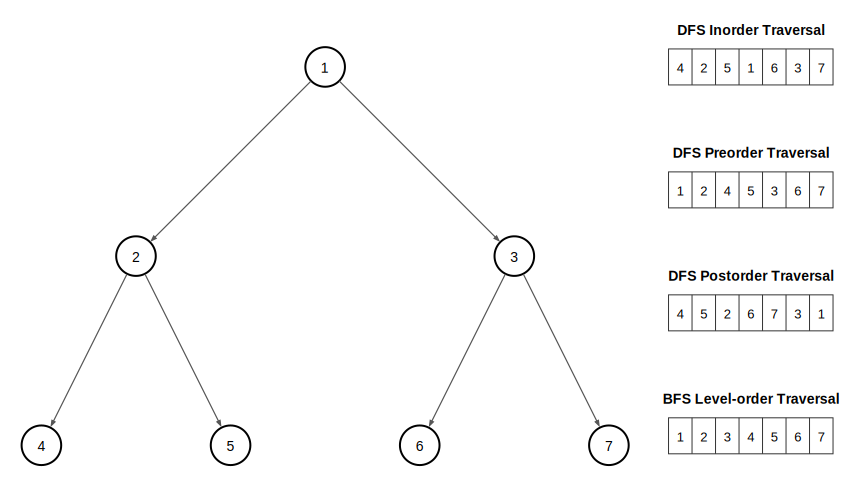

In [45]:
from graphviz import Digraph

dot = Digraph(engine="neato")
dot.attr(overlap="false", splines="false", bgcolor="white", pad="0.3")

dot.attr("edge", color="#555555", penwidth="1.2", arrowsize="0.5")

tree = {
    "1": (-2, 3.0),
    "2": (-4, 1.0),
    "3": (0, 1.0),
    "4": (-5, -1.0),
    "5": (-3, -1.0),
    "6": (-1, -1.0),
    "7": (1, -1.0),
}

for label, (x, y) in tree.items():
    dot.node(
        label,
        pos=f"{x},{y}!",
        fontname="Helvetica",
        fontsize="14",
        shape="circle",
        style="setlinewidth(2)",
        width="0.55",
        fixedsize="true",
    )

for a, b in [("1", "2"), ("1", "3"), ("2", "4"), ("2", "5"), ("3", "6"), ("3", "7")]:
    dot.edge(a, b)

rx = 2.5
arrays = [
    ("DFS Inorder", [4, 2, 5, 1, 6, 3, 7], 3.0),
    ("DFS Preorder", [1, 2, 4, 5, 3, 6, 7], 1.7),
    ("DFS Postorder", [4, 5, 2, 6, 7, 3, 1], 0.4),
    ("BFS Level-order", [1, 2, 3, 4, 5, 6, 7], -0.9),
]

for name, vals, y in arrays:
    arr = " | ".join(f" {v} " for v in vals)

    dot.node(
        f"l_{name}",
        label=f"{name} Traversal",
        pos=f"{rx},{y + 0.4}!",
        shape="plain",
        fontname="Helvetica-Bold",
        fontsize="14",
        fixedsize="false",
    )

    dot.node(
        f"a_{name}",
        label=arr,
        pos=f"{rx},{y}!",
        shape="record",
        style="setlinewidth(1)",
        color="#333333",
        fontname="Helvetica",
        fontsize="13",
        fixedsize="false",
    )

dot